In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings for cleaner output
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [13]:
np.random.seed(42)  # Ensures reproducible results

n = 600
categories = ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports', 'Books']
regions = ['North', 'South', 'East', 'West']

category_price_range = {
    'Electronics': (150, 800),
    'Clothing': (20, 120),
    'Home & Kitchen': (30, 250),
    'Sports': (25, 180),
    'Books': (10, 60)
}

dates = pd.date_range(start='2024-01-01', end='2024-12-31', periods=n)

rows = []
for i in range(n):
    category = np.random.choice(categories)
    region = np.random.choice(regions)
    low, high = category_price_range[category]
    unit_price = round(np.random.uniform(low, high), 2)
    units_sold = np.random.randint(1, 15)
    discount_percent = np.random.choice([0, 5, 10, 15, 20], p=[0.4, 0.25, 0.2, 0.1, 0.05])
    gross_revenue = unit_price * units_sold
    revenue = round(gross_revenue * (1 - discount_percent / 100), 2)
    customer_age = np.random.randint(18, 70)
    base_satisfaction = 3.2 + (discount_percent * 0.02) + np.random.normal(0, 0.8)
    customer_satisfaction = int(np.clip(round(base_satisfaction), 1, 5))

    rows.append({
        'Order_ID': f'ORD{1000 + i}',
        'Order_Date': dates[i].date(),
        'Product_Category': category,
        'Region': region,
        'Units_Sold': units_sold,
        'Unit_Price': unit_price,
        'Discount_Percent': discount_percent,
        'Revenue': revenue,
        'Customer_Age': customer_age,
        'Customer_Satisfaction': customer_satisfaction
    })

df = pd.DataFrame(rows)
df.to_csv('sales_data.csv', index=False)
print("Dataset created and saved as 'sales_data.csv'")
print("Shape:", df.shape)

Dataset created and saved as 'sales_data.csv'
Shape: (600, 10)


In [14]:
df = pd.read_csv('sales_data.csv')
df.head()

,Order_ID,Order_Date,Product_Category,Region,Units_Sold,Unit_Price,Discount_Percent,Revenue,Customer_Age,Customer_Satisfaction
0,ORD1000,2024-01-01,Sports,North,8,53.43,5,406.07,56,3
1,ORD1001,2024-01-01,Home & Kitchen,West,8,103.42,10,744.62,39,3
2,ORD1002,2024-01-02,Books,South,14,46.10,0,645.40,38,4
3,ORD1003,2024-01-02,Books,West,11,11.15,5,116.52,59,5
4,ORD1004,2024-01-03,Sports,West,14,81.79,0,1145.06,68,3


In [15]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               600 non-null    object 
 1   Order_Date             600 non-null    object 
 2   Product_Category       600 non-null    object 
 3   Region                 600 non-null    object 
 4   Units_Sold             600 non-null    int64  
 5   Unit_Price             600 non-null    float64
 6   Discount_Percent       600 non-null    int64  
 7   Revenue                600 non-null    float64
 8   Customer_Age           600 non-null    int64  
 9   Customer_Satisfaction  600 non-null    int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 47.0+ KB
None

Missing Values:
Order_ID                 0
Order_Date               0
Product_Category         0
Region                   0
Units_Sold               0
Unit_Price               0
Discount_P

,Units_Sold,Unit_Price,Discount_Percent,Revenue,Customer_Age,Customer_Satisfaction
count,600.000000,600.00000,600.000000,600.000000,600.000000,600.000000
mean,7.688333,168.27740,6.000000,1241.044917,43.595000,3.333333
std,3.958195,182.80539,5.885666,1687.835132,15.255344,0.834696
min,1.000000,10.29000,0.000000,9.270000,18.000000,1.000000
25%,4.000000,50.81250,0.000000,253.595000,30.000000,3.000000
50%,8.000000,101.60000,5.000000,605.555000,44.000000,3.000000
75%,11.000000,189.30250,10.000000,1434.045000,57.000000,4.000000
max,14.000000,794.32000,20.000000,10274.180000,69.000000,5.000000


In [16]:
avg_revenue = df['Revenue'].mean()
avg_units_sold = df['Units_Sold'].mean()
avg_satisfaction = df['Customer_Satisfaction'].mean()

print(f"Average Revenue per Order: {avg_revenue:.2f}")
print(f"Average Units Sold per Order: {avg_units_sold:.2f}")
print(f"Average Customer Satisfaction: {avg_satisfaction:.2f}")

revenue_by_category = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)
print("\nTotal Revenue by Product Category:")
print(revenue_by_category)

satisfaction_by_region = df.groupby('Region')['Customer_Satisfaction'].mean().sort_values(ascending=False)
print("\nAverage Customer Satisfaction by Region:")
print(satisfaction_by_region)

Average Revenue per Order: 1241.04
Average Units Sold per Order: 7.69
Average Customer Satisfaction: 3.33

Total Revenue by Product Category:
Product_Category
Electronics       443166.35
Home & Kitchen    121303.53
Sports             86202.49
Clothing           60250.15
Books              33704.43
Name: Revenue, dtype: float64

Average Customer Satisfaction by Region:
Region
East     3.441860
West     3.357143
South    3.350318
North    3.206250
Name: Customer_Satisfaction, dtype: float64


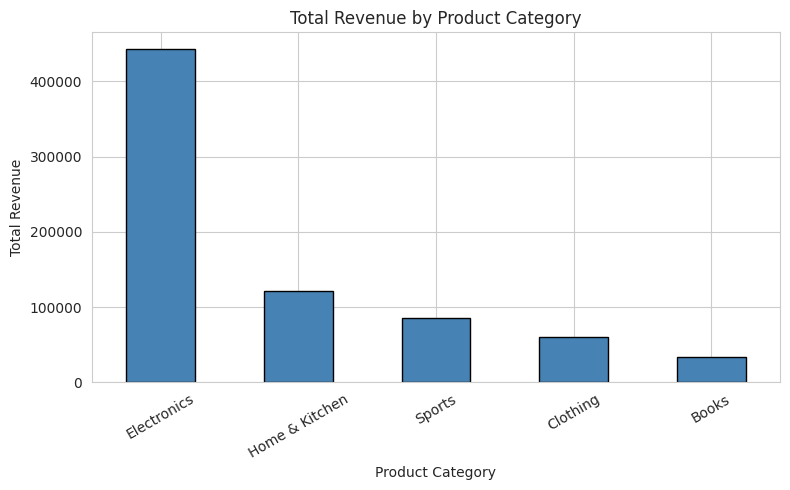

In [17]:
plt.figure(figsize=(8, 5))
revenue_by_category.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

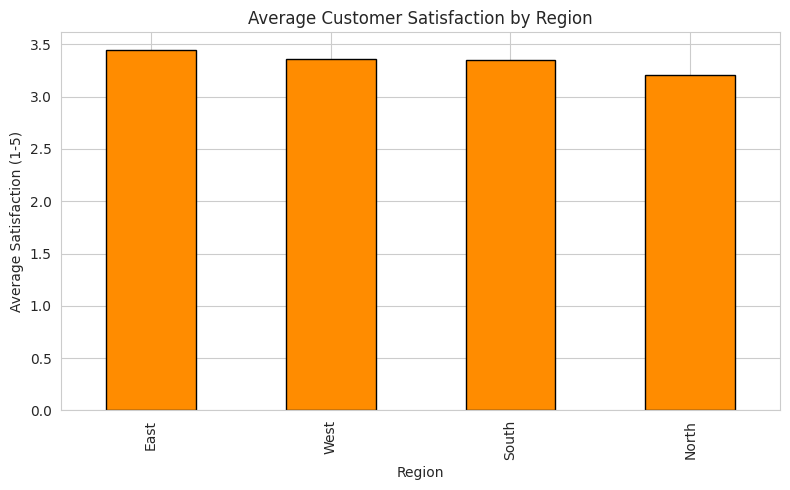

In [18]:
plt.figure(figsize=(8, 5))
satisfaction_by_region.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Average Customer Satisfaction by Region')
plt.xlabel('Region')
plt.ylabel('Average Satisfaction (1-5)')
plt.tight_layout()
plt.show()

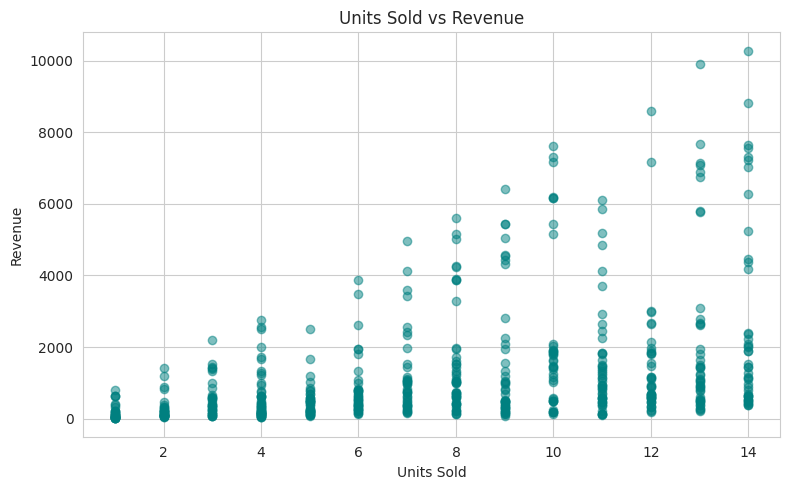

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Units_Sold'], df['Revenue'], alpha=0.5, c='teal')
plt.title('Units Sold vs Revenue')
plt.xlabel('Units Sold')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

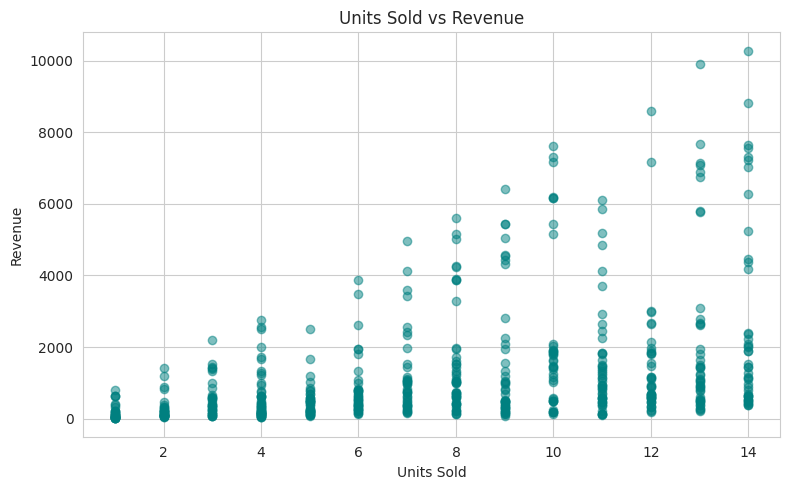

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Units_Sold'], df['Revenue'], alpha=0.5, c='teal')
plt.title('Units Sold vs Revenue')
plt.xlabel('Units Sold')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

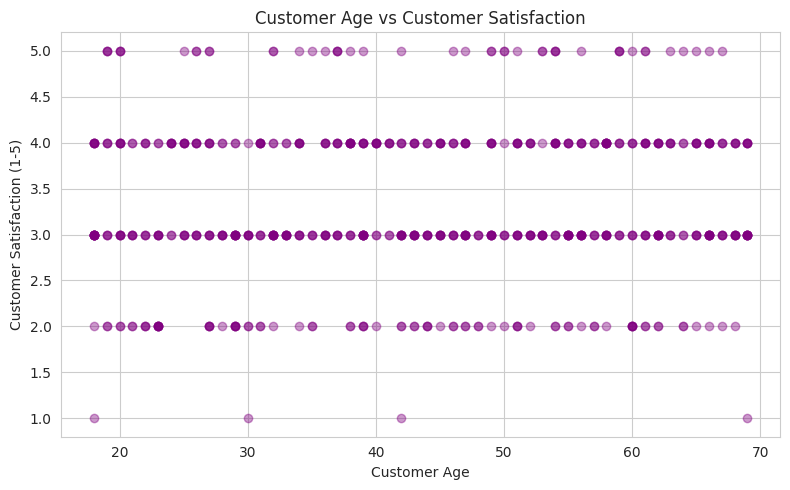

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Customer_Age'], df['Customer_Satisfaction'], alpha=0.4, c='purple')
plt.title('Customer Age vs Customer Satisfaction')
plt.xlabel('Customer Age')
plt.ylabel('Customer Satisfaction (1-5)')
plt.tight_layout()
plt.show()

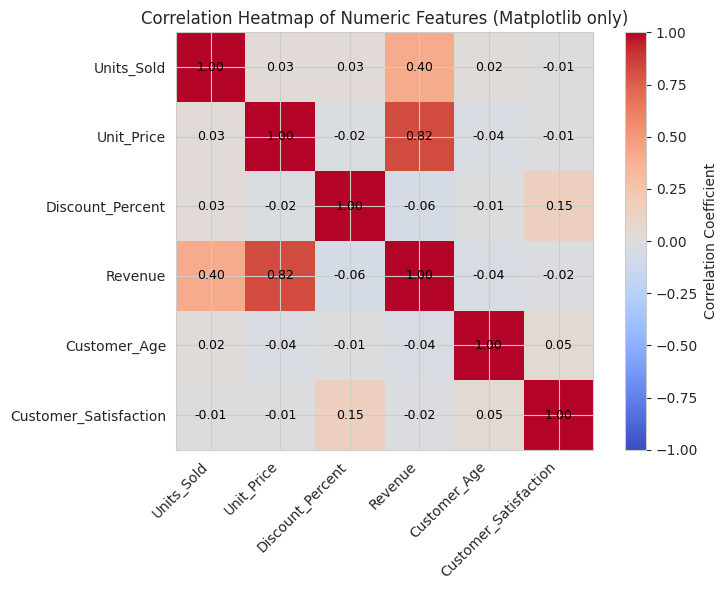

In [22]:
numeric_cols = ['Units_Sold', 'Unit_Price', 'Discount_Percent', 'Revenue', 'Customer_Age', 'Customer_Satisfaction']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)

# Annotate each cell with the correlation value
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha='center', va='center', color='black', fontsize=9)

plt.colorbar(im, label='Correlation Coefficient')
plt.title('Correlation Heatmap of Numeric Features (Matplotlib only)')
plt.tight_layout()
plt.show()